# **Pós Graduação - Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes – Colocação em Funcionamento**

---

### **Sessão 2 — Colocação em Funcionamento**
#### **2.1 — Filtragem dos Dados**

> Neste notebook vamos explorar **técnicas de filtragem** aplicadas a **séries temporais**, um passo crucial antes do treino de modelos baseados em **Redes Neuronais Recorrentes** (RNNs), como as **LSTM**.  
>  
> Será demonstrado como diferentes abordagens de filtragem (e.g., *Média Móvel*, *Savitzky-Golay*, e *Filtros Passa-Baixo*) impactam o desempenho do modelo.

---
> *Prof. Sérgio D. Correia, Maio 2026 [2025/26, 2º Semestre]*

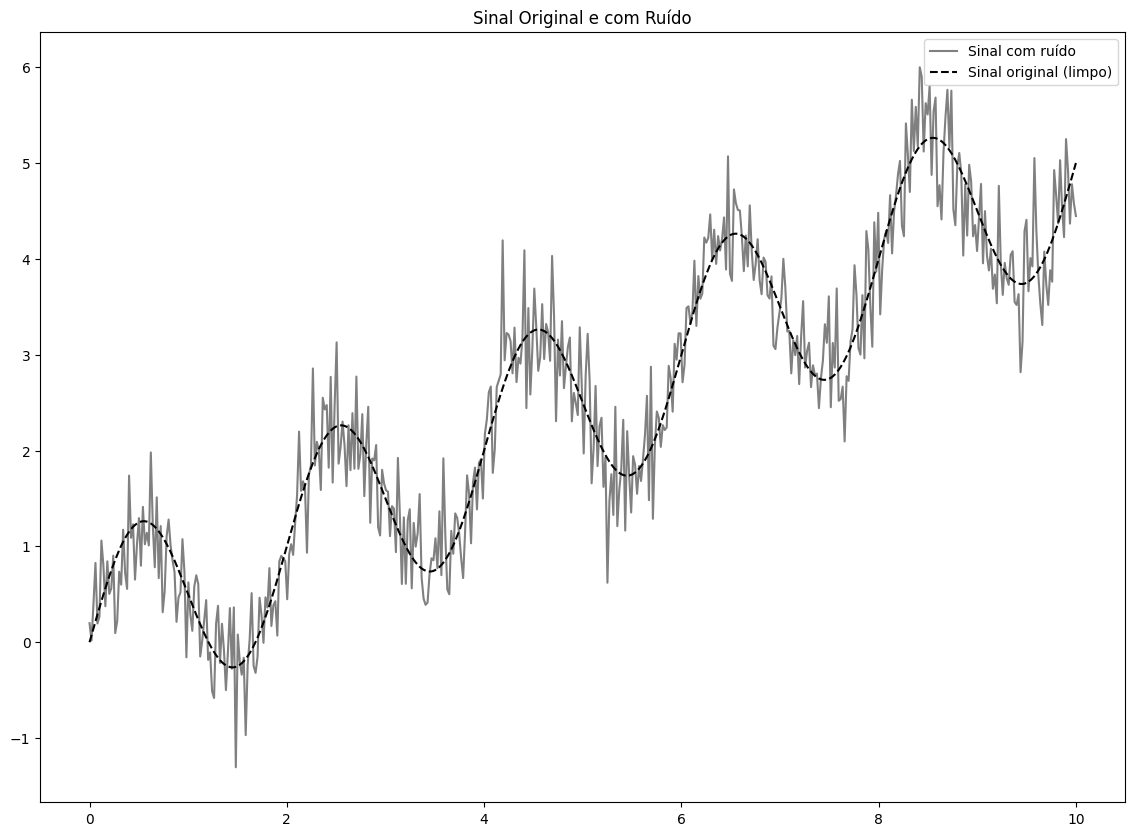

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import stats
from scipy.fftpack import fft, ifft

# 1. Criar sinal com tendência + ruído
np.random.seed(42)
t = np.linspace(0, 10, 500)
sinal_limpo = np.sin(2 * np.pi * 0.5 * t) + 0.5 * t
ruido = np.random.normal(0, 0.4, size=t.shape)
sinal_ruidoso = sinal_limpo + ruido

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_ruidoso, label='Sinal com ruído', color='gray')
plt.plot(t, sinal_limpo, label='Sinal original (limpo)', color='black', linestyle='--')
plt.title("Sinal Original e com Ruído")
plt.legend()

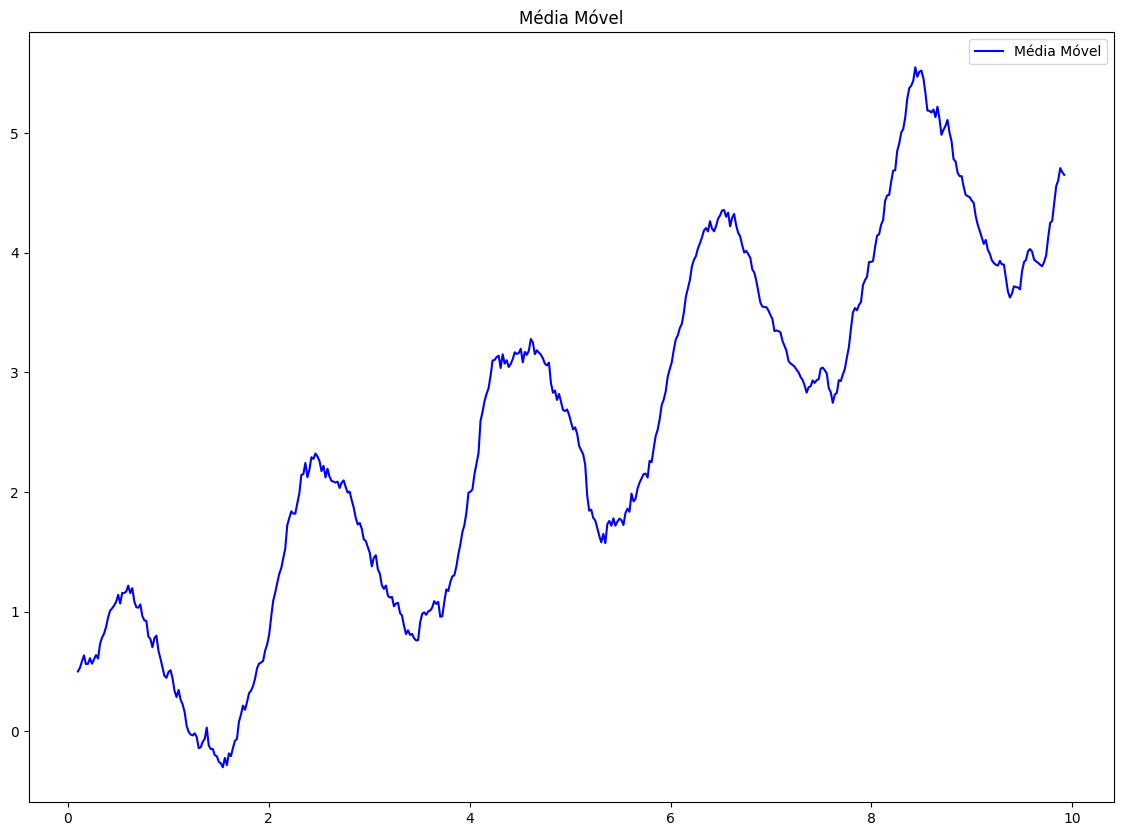

In [ ]:
# --- MÉTODO 1: Média Móvel ---
window_size = 10
sinal_movel = pd.Series(sinal_ruidoso).rolling(window=window_size, center=True).mean()

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_movel, label='Média Móvel', color='blue')
plt.title("Média Móvel")
plt.legend()

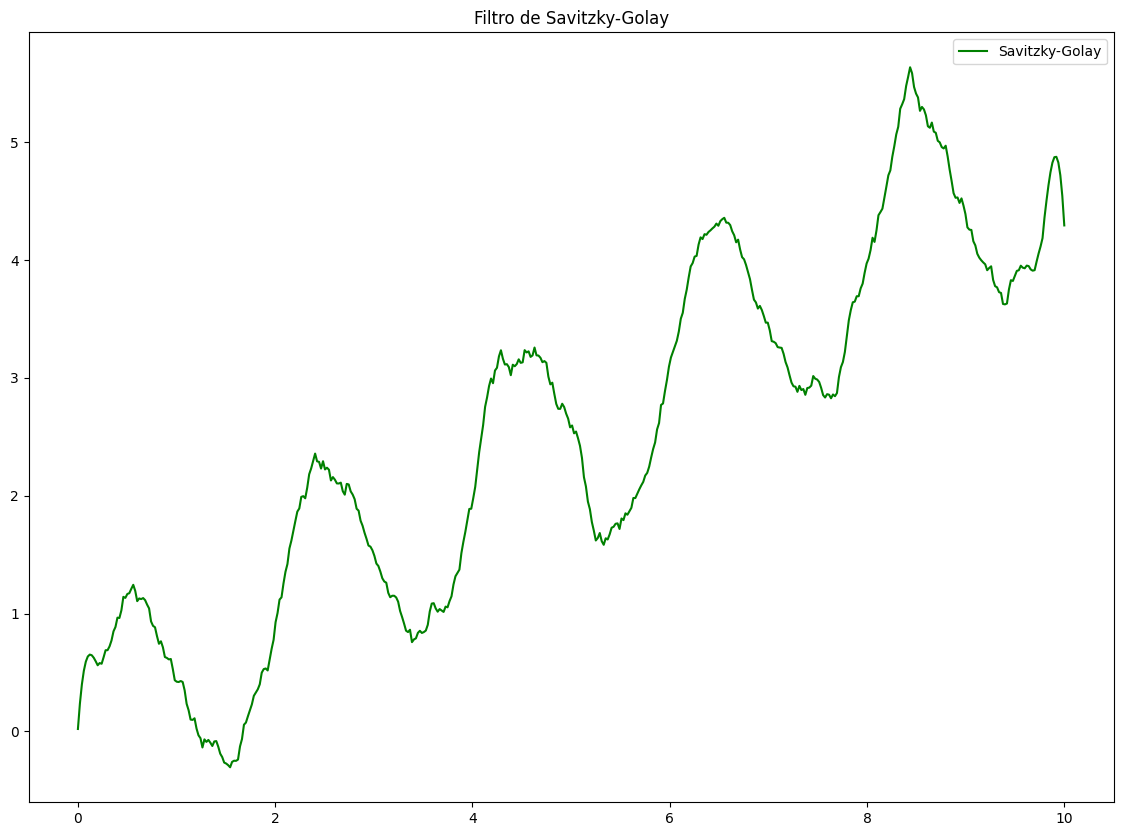

In [ ]:

# --- MÉTODO 2: Savitzky-Golay ---
sinal_savgol = savgol_filter(sinal_ruidoso, window_length=21, polyorder=3)

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_savgol, label='Savitzky-Golay', color='green')
plt.title("Filtro de Savitzky-Golay")
plt.legend()

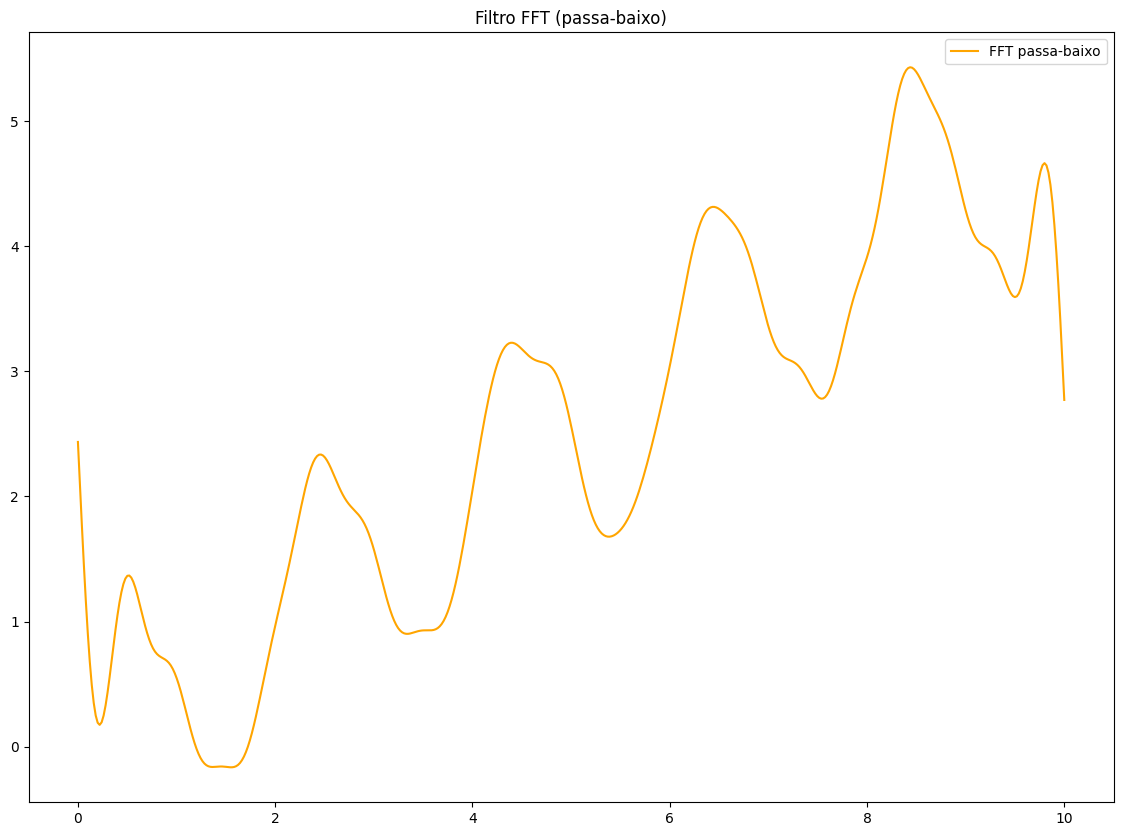

In [ ]:
# --- MÉTODO 3: Filtro Passa-Baixo (FFT) ---
fft_sinal = fft(sinal_ruidoso)
frequencias = np.fft.fftfreq(len(t), d=t[1] - t[0])
cutoff = 2  # Limite de frequência
fft_filtrado = fft_sinal.copy()
fft_filtrado[np.abs(frequencias) > cutoff] = 0
sinal_fft_filtrado = np.real(ifft(fft_filtrado))

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_fft_filtrado, label='FFT passa-baixo', color='orange')
plt.title("Filtro FFT (passa-baixo)")
plt.legend()


# **Pós Graduação - Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes – Colocação em Funcionamento**

---

### **Sessão 2 — Colocação em Funcionamento**
#### **2.2 — Normalização dos Dados**

> Neste notebook vamos explorar **técnicas de normalização** aplicadas a **séries temporais**, um passo crucial antes do treino de modelos baseados em **Redes Neuronais Recorrentes** (RNNs), como as **LSTM**.  
>  
> Será demonstrado como diferentes abordagens de normalização (e.g., *min-max scaling*, *standardization*) impactam o desempenho do modelo.

---
> *Prof. Sérgio D. Correia, Maio 2026 [2025/26, 2º Semestre]*

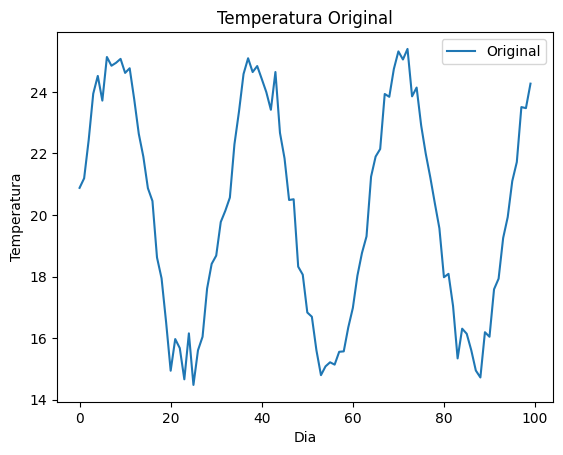

In [1]:
# ===============================================================
# Criação de Dados de Simulação
# ===============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt

# Simular uma série temporal (ex: temperatura ao longo de 100 dias)
np.random.seed(0)
dias = np.arange(100)
temperatura = 20 + 5 * np.sin(0.2 * dias) + np.random.normal(0, 0.5, size=100)
serie = pd.DataFrame({'dia': dias, 'temperatura': temperatura})

# Visualizar a série original
plt.plot(serie['dia'], serie['temperatura'], label='Original')
plt.title("Temperatura Original")
plt.xlabel("Dia")
plt.ylabel("Temperatura")
plt.legend()
plt.show()


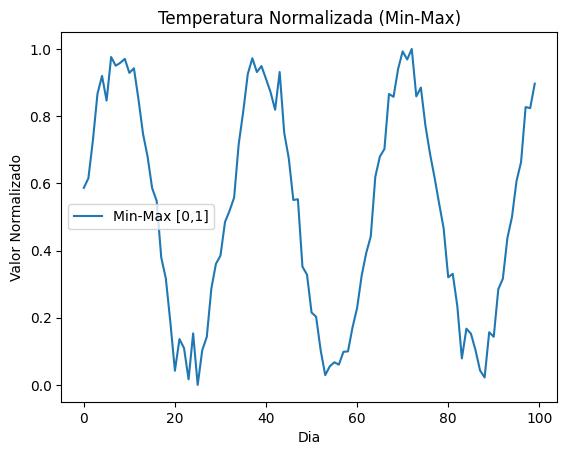

In [2]:
# ===============================================================
# 1. Min-Max Normalization [0 1]
# ===============================================================

scaler_minmax = MinMaxScaler(feature_range=(0, 1))
temperatura_norm = scaler_minmax.fit_transform(serie[['temperatura']])

plt.plot(dias, temperatura_norm, label='Min-Max [0,1]')
plt.title("Temperatura Normalizada (Min-Max)")
plt.xlabel("Dia")
plt.ylabel("Valor Normalizado")
plt.legend()
plt.show()


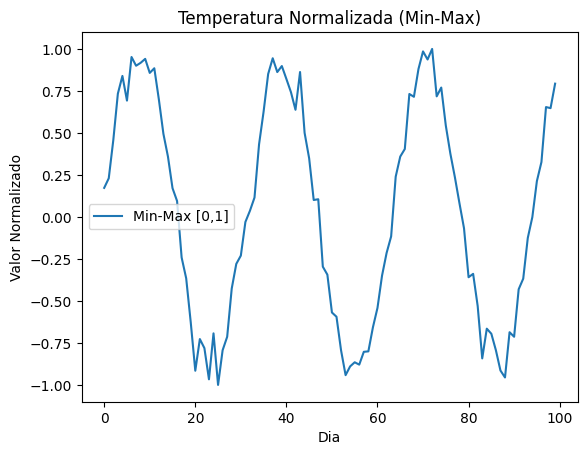

In [3]:
# ===============================================================
# 1. Min-Max Normalization [-1 1]
# ===============================================================

scaler_minmax = MinMaxScaler(feature_range=(-1, 1))
temperatura_norm = scaler_minmax.fit_transform(serie[['temperatura']])

plt.plot(dias, temperatura_norm, label='Min-Max [0,1]')
plt.title("Temperatura Normalizada (Min-Max)")
plt.xlabel("Dia")
plt.ylabel("Valor Normalizado")
plt.legend()
plt.show()

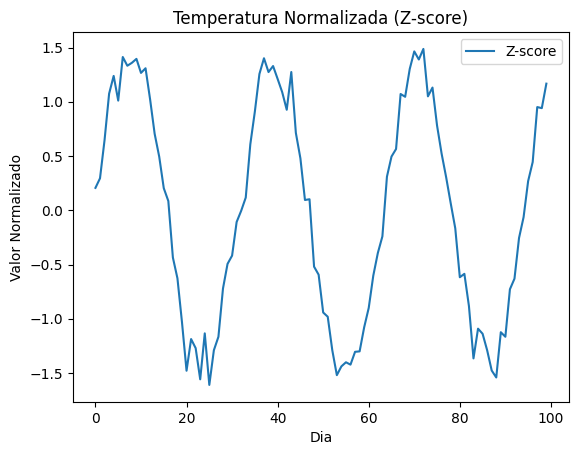

In [4]:
# ===============================================================
# 2. Z-score (Standardization)
# ===============================================================

scaler_std = StandardScaler()
temperatura_std = scaler_std.fit_transform(serie[['temperatura']])

plt.plot(dias, temperatura_std, label='Z-score')
plt.title("Temperatura Normalizada (Z-score)")
plt.xlabel("Dia")
plt.ylabel("Valor Normalizado")
plt.legend()
plt.show()


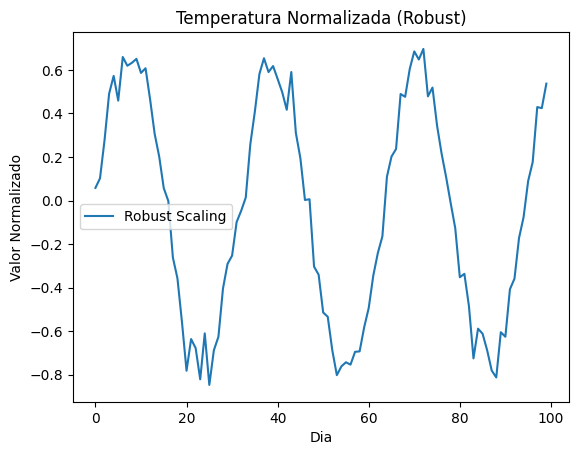

In [5]:
# ===============================================================
# 3. Robust Scaling (mediana e IQR)
# ===============================================================

scaler_robust = RobustScaler()
temperatura_robust = scaler_robust.fit_transform(serie[['temperatura']])

plt.plot(dias, temperatura_robust, label='Robust Scaling')
plt.title("Temperatura Normalizada (Robust)")
plt.xlabel("Dia")
plt.ylabel("Valor Normalizado")
plt.legend()
plt.show()


# **Pós Graduação - Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes – Colocação em Funcionamento**

---

### **Sessão 2 — Fundamentos**
#### **2.3 — Dataset Dados Financeiros**

> Neste notebook vamos explorar **datasets** aplicadas a **dados financeiros**, um passo parao treino de modelos baseados em **Redes Neuronais Recorrentes** (RNNs), como as **LSTM**.  
>  
> Será demonstrado como recolher dados de ativos financeiros, a partir da **Yahoo Finance**, procedendo também à sua **Normalização**.

---
> *Prof. Sérgio D. Correia, Maio 2026 [2025/26, 2º Semestre]*

In [1]:
#Instala e importa bibliotecas
!pip install yfinance --quiet

import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import pandas as pd

In [2]:
#Carregar dados da Apple (últimos 6 meses)
dados = yf.download("AAPL", period="6mo")

/tmp/ipykernel_55074/1998308021.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download("AAPL", period="6mo")
[*********************100%***********************]  1 of 1 completed


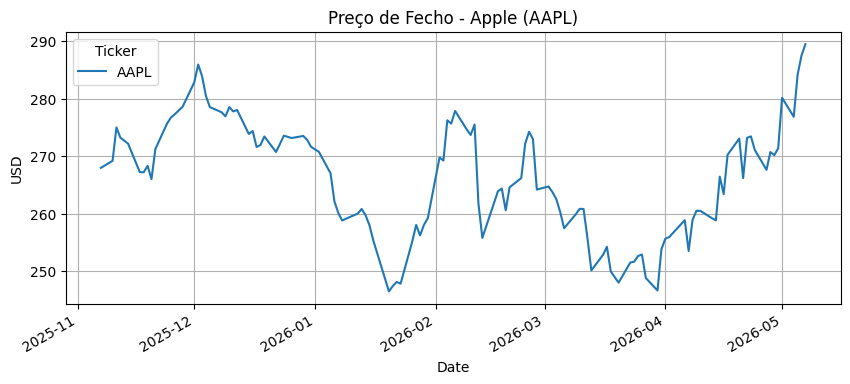

In [3]:
#Mostrar apenas o fecho
dados['Close'].plot(title='Preço de Fecho - Apple (AAPL)', figsize=(10, 4), grid=True)
plt.ylabel('USD')
plt.show()

In [4]:
#Selecionar Abertura, Máximo, Mínimo e Fecho
valores = dados[['Open', 'High', 'Low', 'Close']]

/tmp/ipykernel_55074/2459678251.py:4: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(valores.index, valores[coluna], label=coluna)


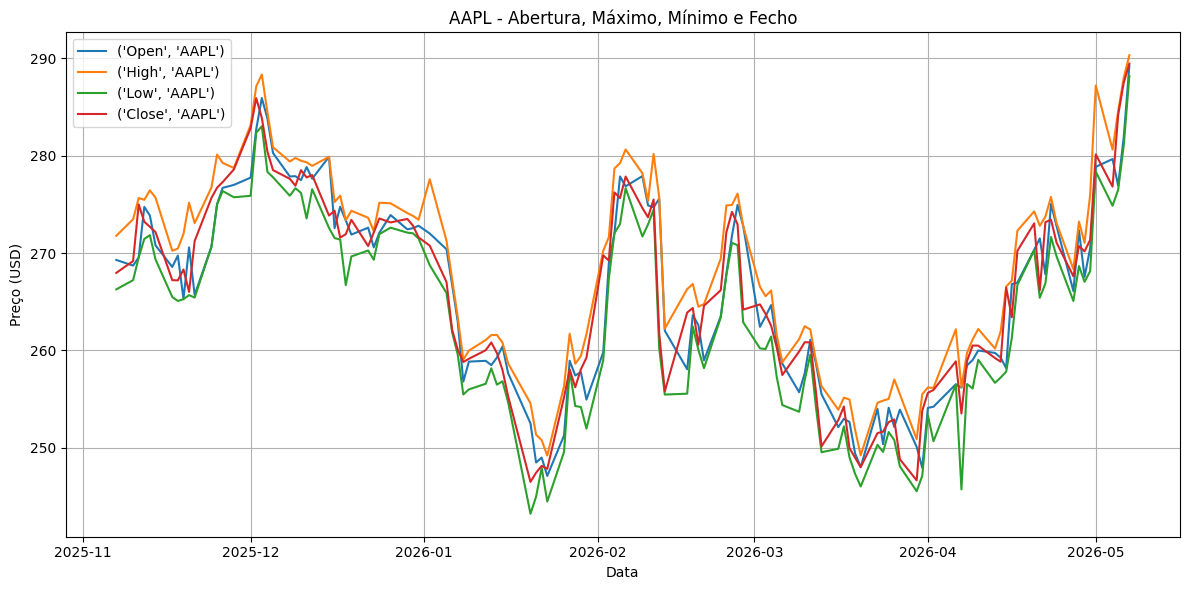

In [5]:

#Plot conjunto
plt.figure(figsize=(12, 6))
for coluna in valores.columns:
    plt.plot(valores.index, valores[coluna], label=coluna)
plt.title('AAPL - Abertura, Máximo, Mínimo e Fecho')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **Vamos Aplicar Normalização**
#### **Ver RNN_Session02_Script02_Normalização.ipynb**

>  Consideramos MinMaxScaler, StandardScaler, RobustScaler











In [6]:
#Aplicar Normalizações
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

/tmp/ipykernel_55074/766668931.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)


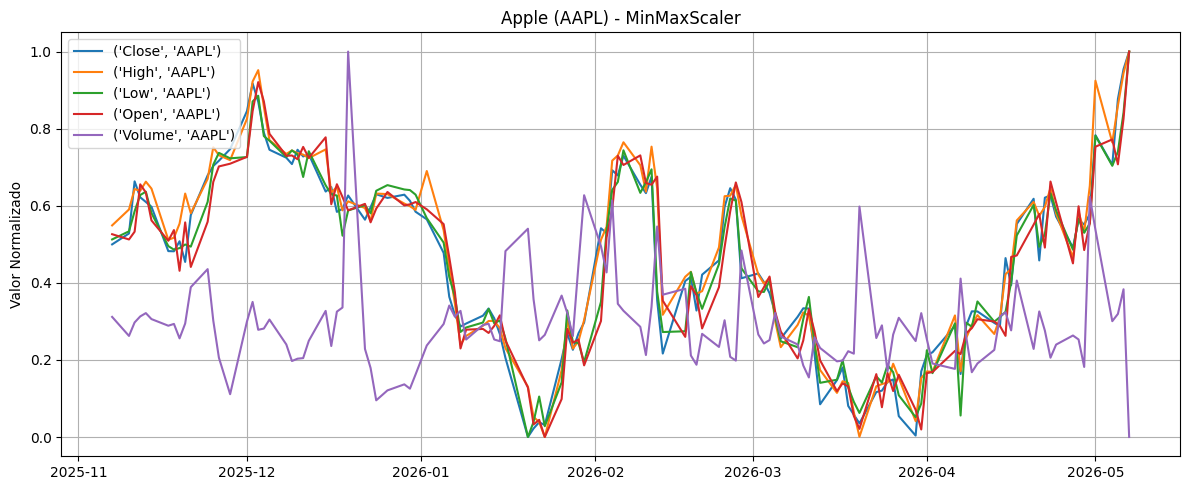

/tmp/ipykernel_55074/766668931.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)


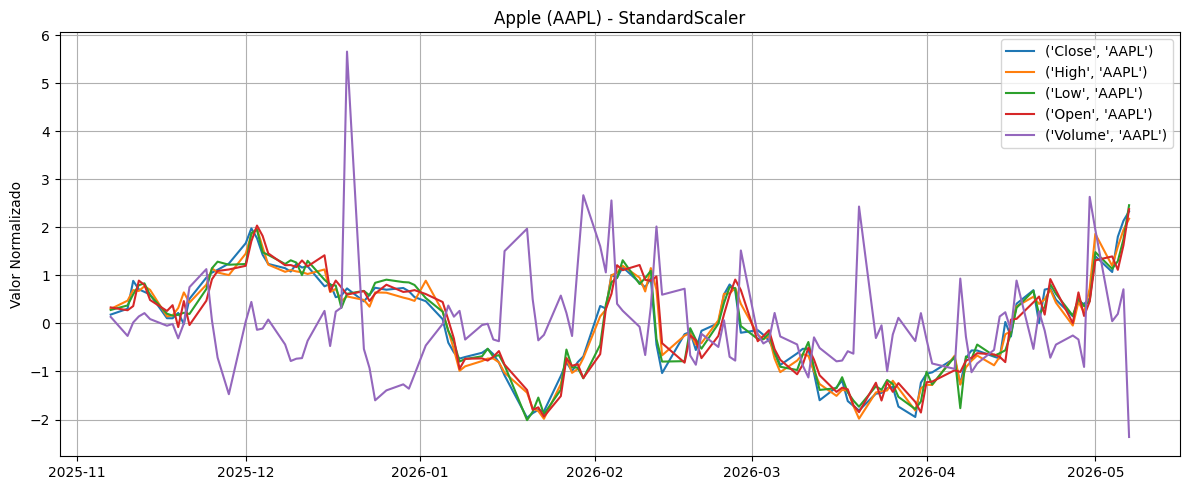

/tmp/ipykernel_55074/766668931.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)


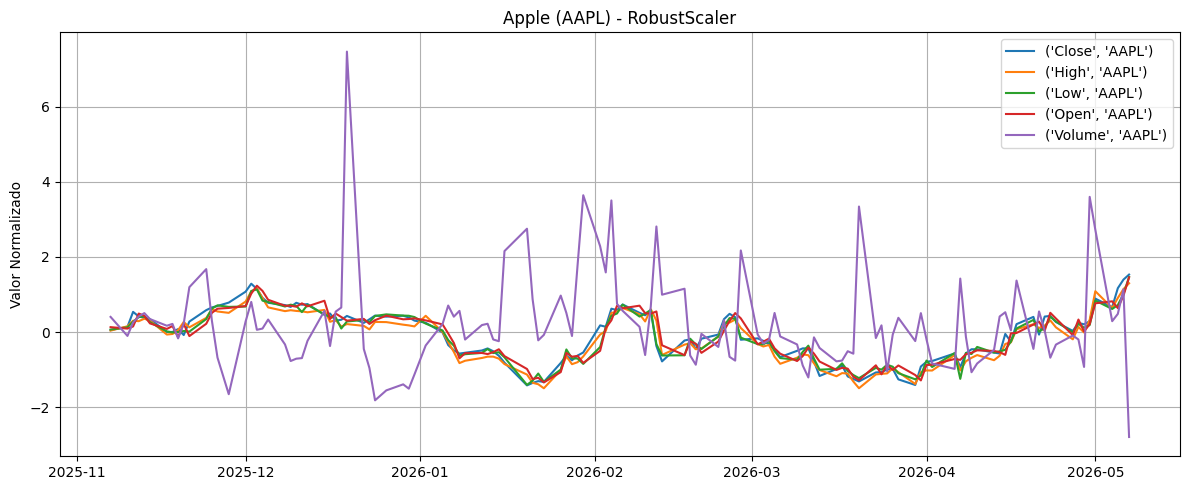

In [7]:
#Aplicar e plotar cada normalização
for nome, scaler in scalers.items():
    dados_scaled = scaler.fit_transform(dados)
    df_scaled = pd.DataFrame(dados_scaled, index=dados.index, columns=dados.columns)

    # 📊 Plot
    plt.figure(figsize=(12, 5))
    for coluna in df_scaled.columns:
        plt.plot(df_scaled.index, df_scaled[coluna], label=coluna)
    plt.title(f'Apple (AAPL) - {nome}')
    plt.ylabel('Valor Normalizado')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# **Pós Graduação - Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes – Colocação em Funcionamento**

---

### **Sessão 2 — Fundamentos**
#### **2.4 — Dataset Dados Financeiros**

> Neste notebook vamos criar uma rede **LSTM** para predição de **dados financeiros**.  
>  
> Será demonstrado como
>> (1) Carregar dados de ativos financeiros, a partir da **Yahoo Finance**

>> (2) Normalização dos dados.

>> (3) Criação da rede.

>> (4) Treino da rede.

---
> *Prof. Sérgio D. Correia, Maio 2026 [2025/26, 2º Semestre]*

In [1]:
#Instalação de pacotes
!pip install yfinance --quiet

In [2]:
#Importações
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
#Carregar dados (apenas fecho)
dados = yf.download('AAPL', period='1y')
fecho = dados[['Close']]

/tmp/ipykernel_1923/3592678.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download('AAPL', period='1y')
[*********************100%***********************]  1 of 1 completed


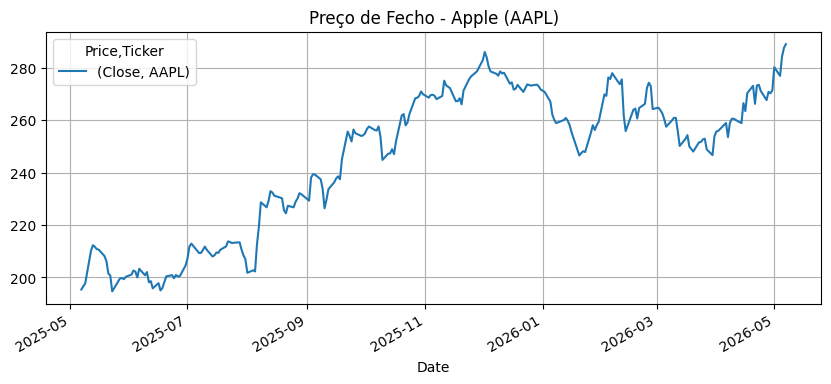

In [4]:
#Visualização
fecho.plot(title='Preço de Fecho - Apple (AAPL)', figsize=(10, 4))
plt.grid(True)
plt.show()

In [5]:
#Normalizar com MinMaxScaler
scaler = MinMaxScaler()
fecho_scaled = scaler.fit_transform(fecho)

In [6]:
#Criar dados sequenciais para LSTM
def cria_sequencias(dataset, n_steps):
    X, y = [], []
    for i in range(n_steps, len(dataset)):
        X.append(dataset[i - n_steps:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

n_steps = 20  # dias anteriores a usar
X, y = cria_sequencias(fecho_scaled, n_steps)

In [7]:
#Ajustar forma para LSTM [amostras, passos, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

In [8]:
#Criar modelo LSTM simples
modelo = Sequential()
modelo.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
modelo.add(Dense(1))
modelo.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


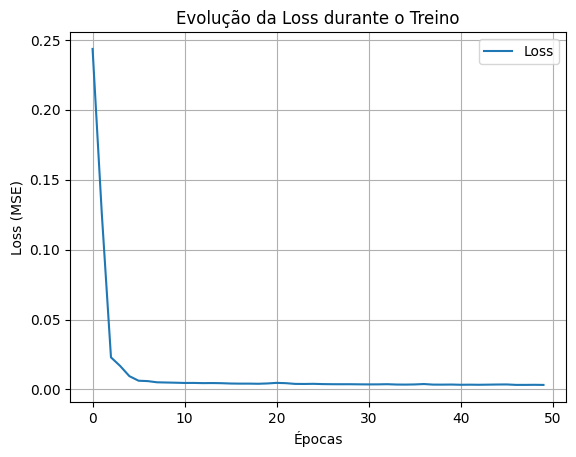

In [9]:
#Treinar o modelo
history = modelo.fit(X, y, epochs=50, verbose=0)

# 5. Plot da loss
plt.plot(history.history['loss'], label='Loss')
plt.title('Evolução da Loss durante o Treino')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
#Prever próximos N dias
n_dias_prever = 7
entrada = fecho_scaled[-n_steps:].reshape(1, n_steps, 1)
previsoes = []

for _ in range(n_dias_prever):
    prox_valor = modelo.predict(entrada)[0][0]
    previsoes.append(prox_valor)
    nova_entrada = np.append(entrada[:, 1:, :], [[[prox_valor]]], axis=1)
    entrada = nova_entrada

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [11]:
#Inverter normalização
previsoes = scaler.inverse_transform(np.array(previsoes).reshape(-1, 1))

In [12]:
#Criar índice temporal para os dias seguintes
ult_data = fecho.index[-1]
datas_prev = pd.date_range(start=ult_data + pd.Timedelta(days=1), periods=n_dias_prever, freq='B')  # Dias úteis


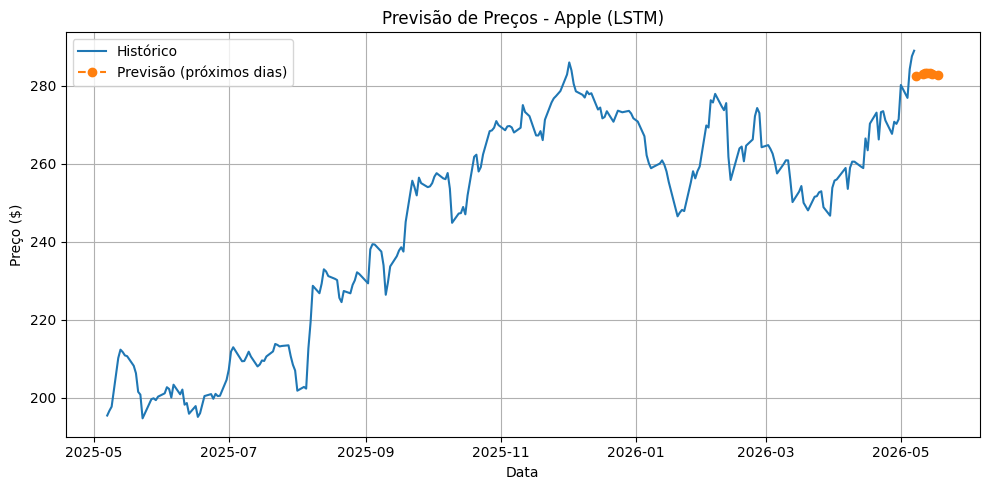

In [13]:
#Plot resultado
plt.figure(figsize=(10, 5))
plt.plot(fecho.index, fecho.values, label='Histórico')
plt.plot(datas_prev, previsoes, label='Previsão (próximos dias)', linestyle='--', marker='o')
plt.title('Previsão de Preços - Apple (LSTM)')
plt.xlabel('Data')
plt.ylabel('Preço ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()